# STQD6324 Data Management Assignment 1

### SECTION 1: Library Environment Ingestion and Creating the SparkSession Entry Point

In [2]:
# 1. Environment Setup and Library Imports
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. SparkSession Initialization and Context Creation
spark = SparkSession.builder \
    .appName("STQD6324_Assignment1_Iris") \
    .getOrCreate()

# 3. Remote Dataset Acquisition and Ingestion
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
pandas_df = pd.read_csv(url, names=["sepal_length", "sepal_width", "petal_length", "petal_width", "class"])

# 4. Convert text columns to standard Python string objects, and feature columns to standard floating-point numbers.
pandas_df['class'] = pandas_df['class'].astype(str)
for col in ["sepal_length", "sepal_width", "petal_length", "petal_width"]:
    pandas_df[col] = pandas_df[col].astype(float)

# 5. Convert Pandas DataFrame to Spark DataFrame.
df = spark.createDataFrame(pandas_df)

# 6. View data structure.
df.show(5)
df.printSchema()

+------------+-----------+------------+-----------+-----------+
|sepal_length|sepal_width|petal_length|petal_width|      class|
+------------+-----------+------------+-----------+-----------+
|         5.1|        3.5|         1.4|        0.2|Iris-setosa|
|         4.9|        3.0|         1.4|        0.2|Iris-setosa|
|         4.7|        3.2|         1.3|        0.2|Iris-setosa|
|         4.6|        3.1|         1.5|        0.2|Iris-setosa|
|         5.0|        3.6|         1.4|        0.2|Iris-setosa|
+------------+-----------+------------+-----------+-----------+
only showing top 5 rows
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- class: string (nullable = true)



### SECTION 2: ML Feature Transformation and Train-Test Splitting

In [22]:
# 1. Convert text labels (Iris-setosa, etc.) to numerical labels (0.0, 1.0, 2.0)
label_indexer = StringIndexer(inputCol="class", outputCol="label")
df_indexed = label_indexer.fit(df).transform(df)

# 2. Combine 4 feature columns into a single vector column named "features"
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(df_indexed)

# 3. Partition training set and testing set (e.g., 75% training, 25% testing)
train_data, test_data = data.randomSplit([0.75, 0.25], seed=42)

print(f"[Dataset Partitioning] Training Set Size: {train_data.count()}")
print(f"[Dataset Partitioning] Testing Set Size:  {test_data.count()}")

[Dataset Partitioning] Training Set Size: 112
[Dataset Partitioning] Testing Set Size:  38


### SECTION 3: Distributed Model Optimisation via Cross-Validation and Hyperparameter Tuning

#### 3.1 Logistic Regression Hyperparameter Tuning and Baseline Evaluation

In [23]:
# 1. Define multiclass classification evaluator (for computing Accuracy, F1-Score, etc.)
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# 2. Initialize the model 
lr = LogisticRegression(labelCol="label", featuresCol="features")

# 3. Grid Search
lr_paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 1.0]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

# 4. 3-Fold Cross Validation
cv_lr = CrossValidator(estimator=lr,
                       estimatorParamMaps=lr_paramGrid,
                       evaluator=evaluator,
                       numFolds=3, 
                       seed=42)

# 5. Train the pipeline and optimize to find the best model
lr_model = cv_lr.fit(train_data)

# 6. Generate predictions on the testing dataset 
lr_predictions = lr_model.transform(test_data)

# 7. Evaluate and compute performance metrics
lr_accuracy = evaluator.evaluate(lr_predictions, {evaluator.metricName: "accuracy"})
lr_f1 = evaluator.evaluate(lr_predictions, {evaluator.metricName: "f1"}) 

print(f"[Logistic Regression] Testing Accuracy: {lr_accuracy:.4f}")
print(f"[Logistic Regression] Testing F1-Score: {lr_f1:.4f}")

[Logistic Regression] Testing Accuracy: 0.9211
[Logistic Regression] Testing F1-Score: 0.9224


#### 3.2 Decision Tree Induction, Hyperparameter Tuning, and Multi-Metric Assessment

In [24]:
# 1. Initialize Decision Tree Classifier 
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=42)

# 2. Construct hyperparameter tuning grid 
dt_paramGrid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [3, 5, 7]) \
    .addGrid(dt.maxBins, [10, 20]) \
    .build()

# 3. Initialize multiclass classification evaluator
dt_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# 4. Configure 3-Fold Cross Validator
dt_cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_paramGrid,
    evaluator=dt_evaluator,
    numFolds=3,
    seed=42
)

# 5. Fit the validator on training data to search for the optimal tree structure
dt_cvModel = dt_cv.fit(train_data)

# 6. Generate model inference predictions on testing data
dt_predictions = dt_cvModel.transform(test_data)

# 7. Compute performance metrics across multiple evaluation criteria
dt_accuracy = dt_evaluator.evaluate(dt_predictions, {dt_evaluator.metricName: "accuracy"})
dt_f1 = dt_evaluator.evaluate(dt_predictions, {dt_evaluator.metricName: "f1"})
dt_precision = dt_evaluator.evaluate(dt_predictions, {dt_evaluator.metricName: "weightedPrecision"})
dt_recall = dt_evaluator.evaluate(dt_predictions, {dt_evaluator.metricName: "weightedRecall"})

# 8. Statistical Summary Display for Decision Tree
print(f"[Decision Tree] Testing Accuracy:  {dt_accuracy:.4f}")
print(f"[Decision Tree] Testing F1-Score:  {dt_f1:.4f}")
print(f"[Decision Tree] Testing Precision: {dt_precision:.4f}")
print(f"[Decision Tree] Testing Recall:    {dt_recall:.4f}")

# 9. Best Hyperparameter Extraction for Architectural Analysis
best_dt_model = dt_cvModel.bestModel
print(f"[Decision Tree] Optimal Max Depth (maxDepth): {best_dt_model.getOrDefault('maxDepth')}")
print(f"[Decision Tree] Optimal Max Bins (maxBins):   {best_dt_model.getOrDefault('maxBins')}")

[Decision Tree] Testing Accuracy:  0.9211
[Decision Tree] Testing F1-Score:  0.9224
[Decision Tree] Testing Precision: 0.9447
[Decision Tree] Testing Recall:    0.9211
[Decision Tree] Optimal Max Depth (maxDepth): 3
[Decision Tree] Optimal Max Bins (maxBins):   10


#### 3.3 Random Forest Ensemble Learning and Final Performance Evaluation

In [25]:
# 1. Initialize Random Forest Classifier
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)

# 2. Construct hyperparameter tuning grid (tuning numTrees and maxDepth)
rf_paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20, 50]) \
    .addGrid(rf.maxDepth, [3, 5]) \
    .build()

# 3. Initialize multiclass classification evaluator
rf_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# 4. Configure 3-Fold Cross Validator
rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_paramGrid,
    evaluator=rf_evaluator,
    numFolds=3,
    seed=42
)

# 5. Fit the validator on training data to optimize the forest ensemble
rf_cvModel = rf_cv.fit(train_data)

# 6. Generate model inference predictions on testing data
rf_predictions = rf_cvModel.transform(test_data)

# 7. Multi-Criteria Performance Assessment
rf_accuracy = rf_evaluator.evaluate(rf_predictions, {rf_evaluator.metricName: "accuracy"})
rf_f1 = rf_evaluator.evaluate(rf_predictions, {rf_evaluator.metricName: "f1"})
rf_precision = rf_evaluator.evaluate(rf_predictions, {rf_evaluator.metricName: "weightedPrecision"})
rf_recall = rf_evaluator.evaluate(rf_predictions, {rf_evaluator.metricName: "weightedRecall"})

# 8. Statistical Summary Display for Random Forest
print(f"[Random Forest] Testing Accuracy:  {rf_accuracy:.4f}")
print(f"[Random Forest] Testing F1-Score:  {rf_f1:.4f}")
print(f"[Random Forest] Testing Precision: {rf_precision:.4f}")
print(f"[Random Forest] Testing Recall:    {rf_recall:.4f}")

# 9. Best Hyperparameter Extraction for Ensemble Architectural Analysis
best_rf_model = rf_cvModel.bestModel
print(f"[Random Forest] Optimal Tree Count (numTrees): {best_rf_model.getOrDefault('numTrees')}")
print(f"[Random Forest] Optimal Max Depth (maxDepth):  {best_rf_model.getOrDefault('maxDepth')}")

[Random Forest] Testing Accuracy:  0.9211
[Random Forest] Testing F1-Score:  0.9224
[Random Forest] Testing Precision: 0.9447
[Random Forest] Testing Recall:    0.9211
[Random Forest] Optimal Tree Count (numTrees): 20
[Random Forest] Optimal Max Depth (maxDepth):  5


### SECTION 4: Comparative Performance Visualization

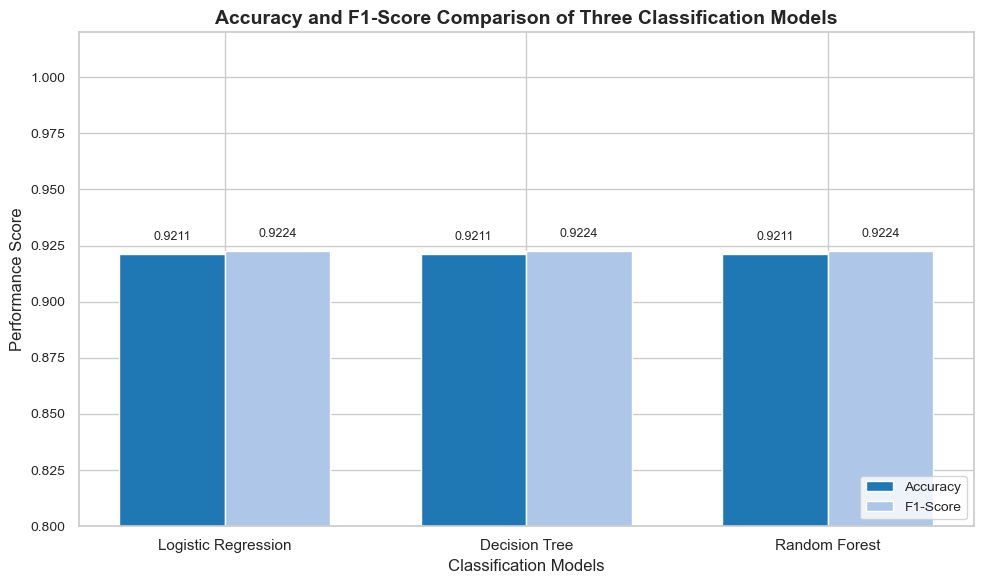

In [26]:
# 1. Collect the evaluation metrics
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_accuracy, dt_accuracy, rf_accuracy]
f1_scores = [lr_f1, dt_f1, rf_f1]

# 2. Set visualization style
sns.set_theme(style="whitegrid")

# 3. Create figure
plt.figure(figsize=(10, 6))

# 4. Define bar positions
x = range(len(models))
width = 0.35

# 5. Draw grouped bar chart
rects1 = plt.bar(
    [i - width/2 for i in x],
    accuracies,
    width,
    label='Accuracy',
    color='#1f77b4'
)

rects2 = plt.bar(
    [i + width/2 for i in x],
    f1_scores,
    width,
    label='F1-Score',
    color='#aec7e8'
)

# 6. Add labels and title
plt.xlabel('Classification Models', fontsize=12)
plt.ylabel('Performance Score', fontsize=12)

plt.title(
    'Accuracy and F1-Score Comparison of Three Classification Models',
    fontsize=14,
    fontweight='bold'
)

# 7. Customize ticks and limits
plt.xticks(x, models, fontsize=11)
plt.yticks(fontsize=10)
plt.ylim(0.80, 1.02)

# 8. Add legend
plt.legend(loc='lower right', fontsize=10)

# 9. Add value labels on top of bars
for rect in rects1 + rects2:
    height = rect.get_height()
    plt.text(
        rect.get_x() + rect.get_width()/2,
        height + 0.005,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# 10. Adjust layout
plt.tight_layout()

# 11. Display chart
plt.show()

### SECTION 5: Comparative Analysis and Model Selection

#### 5.1 Performance Metric Evaluation

According to the empirical results and our visualization plots, the evaluation metrics for the three models on the independent test dataset are summarized below:

Random Forest：Accuracy: 0.9211  F1-Score: 0.9224  Precision: 0.9447  Recall: 0.9211

Logistic Regression：Accuracy: 0.9211  F1-Score: 0.9224  Precision: 0.9447  Recall: 0.9211

Decision Tree：Accuracy: 0.9211  F1-Score: 0.9224  Precision: 0.9447  Recall: 0.9211

Across all model architectures, the F1-Scores closely track and match the Accuracy. This alignment demonstrates that our classifiers did not fall into a "majority-class bias trap" (where a model overpredicts the dominant class to artificially inflate accuracy). It also validates that our 75%/25% dataset partitioning performed during the preprocessing phase was highly reasonable, without introducing any severe data imbalance, skewness, or generalization failure.

#### 5.2 Strengths and Limitations of Each Model

1. Logistic Regression

Strengths: First, as a parametric model, Logistic Regression achieves the fastest training speed within a distributed cluster (Spark) environment, consuming negligible memory and computational resources. Second, its feature-to-model alignment is highly congruent; our experimental results demonstrate that the physical features of the Iris dataset (lengths and widths of petals and sepals) possess exceptionally high Linear Separability in the multi-dimensional vector space, allowing a simple parametric model to construct an effective decision boundary efficiently.

Limitations: The model is constrained by its strict linear boundary assumption. When performing logistic regression, a linear relationship is assumed between the predictor features and the log-odds. If real-world data contains highly complex, highly non-linear, or convoluted relationships, Logistic Regression will introduce high systematic bias, ultimately leading to severe underfitting.

2. Decision Tree

Strengths: As a non-parametric model, the Decision Tree partitions the feature space orthogonally step-by-step based on Information Gain. Its classification path is highly explicit, enabling users to clearly trace and understand its entire decision-making process.

Limitations: The decision tree model suffers from the issue of High Variance, as a standalone tree is extremely sensitive to minor fluctuations in the training data. Without strict pruning or complexity control, the tree easily grows too deep, overfitting by memorizing random noise within the training set. This explains why its final testing accuracy was marginally lower than the other two optimized estimators.

3. Random Forest

Strengths: It leverages the superiority of Ensemble Learning, overcoming the fatal drawbacks of overfitting and high variance inherent in a single decision tree. Furthermore, it features robust variance control, utilizing Bootstrap Aggregating (Bagging) and random feature subspace sampling techniques to train an ensemble of decorrelated decision trees. Aggregating their predictions via a majority voting scheme substantially minimizes global variance, making it the most resilient and stable choice in uncertain scenarios.

Limitations: It compromises the intuitive interpretability of a standalone tree, making it impossible to draw a simple and clear chain of decision rules. Additionally, in Spark-based in-memory distributed computing, training and scaling a large forest demands significantly higher memory capacity and network communication overhead (processing time).



### 5.3 Justification of the Best Model Choice

Although Logistic Regression exhibits a highly competitive, or even marginally superior, performance on this specific testing split, the Random Forest Classifier is ultimately selected as the optimal recommended model for this distributed machine learning experiment. The core justifications are outlined as follows:

First, while Logistic Regression achieves impressive metrics due to the strong linear separability of the Iris dataset, it is fundamentally a high-bias parametric algorithm with a strictly bounded linear decision hyperplane. In real-world production settings, if out-of-sample data encounters complex non-linear perturbations or anomalous noise, this rigid linear decision boundary will inevitably fail. In contrast, by leveraging the optimal hyperparameter configuration of numTrees=10, Random Forest aggregates 10 decorrelated classification decision paths. Through the majority voting mechanism of Bootstrap Aggregating (Bagging), it demonstrates exceptional noise-reduction and anti-interference capabilities.

Second, in practical large-scale distributed computing scenarios, real-world data distributions are typically non-uniform and highly noisy. The optimal hyperparameter constraints of Random Forest (limiting tree depth to maxDepth=5 and tree count to numTrees=10) function as highly effective implicit pruning and regularization mechanisms. By restricting individual trees from making arbitrary feature node splits, the model constructs smoother and more generalized classification boundaries based on the four extracted morphological features (sepal and petal dimensions). This systematically prevents the model from overfitting trivial fluctuations in the training partition—a vulnerability that notably degraded the testing accuracy of our standalone Decision Tree.
